### Data Dictionary (Italian Customs & Aviation Terminology)

**1. Temporal Features (Time & Date).**  
`DATA_PARTENZA`: Departure Date (Full timestamp).  
`ANNO_PARTENZA` / `MESE_PARTENZA` / `GIORNO_PARTENZA`: Year / Month / Day of departure.

**2. Geographical & Airport Features.**  
`AREOPORTO_PARTENZA` / `AREOPORTO_ARRIVO`: Departure / Arrival Airport Code (e.g., FCO, JFK).  
`DESCR_AEREOPORTO_...`: Full Airport Name (e.g., Fiumicino, John F Kennedy).  
`CITTA_PARTENZA` / `CITTA_ARR`: Departure / Arrival City.  
`PAESE_PART` / `PAESE_ARR`: Departure / Arrival Country.  
`CODICE_PAESE_...`: Country Code (e.g., ITA, USA).  
`ZONA` / `3zona`: Geographical routing zone.  

**3. Flight & Airline Info**  
`COMPAGNIA_AEREA` / `compagnia%aerea`: Airline Name.  
`NUMERO_VOLO` / `num volo`: Flight Number.  
`FLAG_TRANSITO`: Indicates if it's a transit flight (Connecting flight).  

**4. Passenger Demographics (Travelers Dataset).**  
`NAZIONALITA` / `3nazionalita`: Passenger Nationality.  
`GENERE`: Gender.  
`FASCIA_ETA` / `FASCIA ETA`: Age Group (e.g., 18-30).  
`TIPO_DOCUMENTO` / `Tipo Documento`: Document used (Passport, ID Card).  

**5. Quantitative Metrics (The Numbers)**  
`TOT` / `tot voli`: Number of alarms for a specific occurenzi.   
`ENTRATI`: Total number of passengers who *entered* the system/country.  
`INVESTIGATI`: Number of passengers *investigated* (Level 1 check).  
`ALLARMATI`: Number of passengers flagged with an *alarm* (Level 2 check/Anomaly).  

**6. Customs & Risk Assessment (The Labels)**  
`OCCORRENZE`: Type of event/occurrence recorded.  
`MOTIVO_ALLARME`: Reason for the alarm/flag. (who has raised the alarm).  
`ESITO_CONTROLLO`: Outcome of the inspection (e.g., Cleared, Rejected, Arrested).  
`codice_rischio` / `flag_rischio`: Risk code/flag (mostly missing data, >98% NaNs).  
`note_operatore`: Customs operator's manual notes (mostly missing data, >98% NaNs).  

In [48]:
#Settings
import pandas as pd
from IPython.display import display
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
import pycountry

In [49]:
# Load datasets
df_alarms = pd.read_csv("ALLARMI.csv")
df_travelers = pd.read_csv("TIPOLOGIA_VIAGGIATORE.csv")

#Renaming columms to english
manual_mapping = {
    "OCCORRENZE": "occurrences",
    "AREOPORTO_ARRIVO": "arrival_airport_iata",
    "AREOPORTO_PARTENZA": "departure_airport_iata",
    "ANNO_PARTENZA": "departure_year",
    "MESE_PARTENZA": "departure_month",
    "DATA_PARTENZA": "departure_date",
    "DESCR_AEREOPORTO_ARR": "arrival_airport_description",
    "DESCR_AEREOPORTO_PART": "departure_airport_description",
    "CITTA_ARR": "arrival_city",
    "CITTA_PARTENZA": "departure_city",
    "CODICE_PAESE_ARR": "arrival_country_code",
    "CODICE_PAESE_PART": "departure_country_code",
    "PAESE_ARR": "arrival_country",
    "PAESE_PART": "departure_country",
    "ZONA": "zone",
    "TOT": "total",
    "MOTIVO_ALLARME": "alarm_reason",
    "note_operatore": "operator_notes",
    "flag_rischio": "risk_flag",
    "Paese Partenza": "departure_country_full",
    "CODICE PAESE ARR": "arrival_country_code_full",
    "3zona": "zone_3",
    "paese%arr": "arrival_country_percentage",
    "tot voli": "total_flights",
    "NAZIONALITA": "nationality",
    "GIORNO_PARTENZA": "departure_day",
    "ENTRATI": "entries",
    "INVESTIGATI": "investigated",
    "ALLARMATI": "alarms",
    "TIPO_DOCUMENTO": "document_type",
    "GENERE": "gender",
    "FASCIA_ETA": "age_group",
    "FLAG_TRANSITO": "transit_flag",
    "COMPAGNIA_AEREA": "airline",
    "NUMERO_VOLO": "flight_number",
    "ESITO_CONTROLLO": "control_outcome",
    "codice_rischio": "risk_code",
    "Tipo_Documento": "document_type2",
    "FASCIA_ETA2": "age_group2",
    "3nazionalita": "nationality_3",
    "compagnia%aerea": "airline%",
    "num volo": "flight number"
}
df_alarms = df_alarms.rename(columns=manual_mapping)
df_travelers = df_travelers.rename(columns=manual_mapping)

it_to_en = {
    'Albania': 'Albania',
    'Algeria': 'Algeria',
    'Antigua e barbuda': 'Antigua and Barbuda',
    'Arabia saudita': 'Saudi Arabia',
    'Argentina': 'Argentina',
    'Armenia': 'Armenia',
    'Azerbaigian': 'Azerbaijan',
    'Bahrain': 'Bahrain',
    'Brasile': 'Brazil',
    'Canada': 'Canada',
    'Capo verde': 'Cabo Verde',
    'Cina': 'China',
    'Corea del sud': 'Korea, Republic of',
    'Cossovo': 'Kosovo',
    'Egitto': 'Egypt',
    'Emirati arabi uniti': 'United Arab Emirates',
    'Etiopia': 'Ethiopia',
    'Georgia': 'Georgia',
    'Giamaica': 'Jamaica',
    'Giappone': 'Japan',
    'Giordania': 'Jordan',
    'Hong kong': 'Hong Kong',
    'India': 'India',
    'Iran': 'Iran, Islamic Republic of',
    'Israele': 'Israel',
    'Kazakistan': 'Kazakhstan',
    'Kenya': 'Kenya',
    'Kuwait': 'Kuwait',
    'Libano': 'Lebanon',
    'Libia': 'Libya',
    'Macedonia': 'North Macedonia',
    'Maldive': 'Maldives',
    'Marocco': 'Morocco',
    'Mauritius': 'Mauritius',
    'Messico': 'Mexico',
    'Moldavia': 'Moldova, Republic of',
    'Montenegro': 'Montenegro',
    'Oman': 'Oman',
    'Qatar': 'Qatar',
    'Regno unito': 'United Kingdom',
    'Repubblica dominicana': 'Dominican Republic',
    'Senegal': 'Senegal',
    'Serbia': 'Serbia',
    'Singapore': 'Singapore',
    'Stati uniti': 'United States',
    'Taiwan': 'Taiwan, Province of China',
    'Tanzania': 'Tanzania, United Republic of',
    'Tunisia': 'Tunisia',
    'Turchia': 'Turkey',
    'Uzbekistan': 'Uzbekistan'
}

city_mapping = {
    'Algeri': 'Algiers',
    'Belgrado': 'Belgrade',
    'Citta Del Messico': 'Mexico City',
    'Filadelfia': 'Philadelphia',
    'Londra': 'London',
    'Nuova Delhi': 'New Delhi',
    'Pechino': 'Beijing',
    'San Paolo': 'Sao Paulo',
    'Skopie': 'Skopje',
    'Smirne': 'Izmir',
    'Tel Aviv Yafo': 'Tel Aviv',
    'St. John\'S': "St. John's",
    'Buenos Aires': 'Buenos Aires',
    'Rio De Janeiro': 'Rio de Janeiro',
    'Abu Dhabi': 'Abu Dhabi',
    'Addis Ababa': 'Addis Ababa',
    'Hong Kong': 'Hong Kong',
    'Kuwait City': 'Kuwait City',
    'Los Angeles': 'Los Angeles',
    'New York': 'New York'
}

iata_mapping = {
    'AUH': {'city': 'Abu Dhabi', 'airport': 'Abu Dhabi International'},
    'ADD': {'city': 'Addis Ababa', 'airport': 'Bole International'},
    'AGA': {'city': 'Agadir', 'airport': 'Agadir Al Massira'},
    'ALG': {'city': 'Algiers', 'airport': 'Houari Boumediene'},
    'ALA': {'city': 'Almaty', 'airport': 'Almaty International'},
    'AMM': {'city': 'Amman', 'airport': 'Queen Alia International'},
    'ANU': {'city': "St. John's", 'airport': 'V.C. Bird International'},
    'ATL': {'city': 'Atlanta', 'airport': 'Hartsfield-Jackson Atlanta International'},
    'ATQ': {'city': 'Amritsar', 'airport': 'Sri Guru Ram Dass Jee International'},
    'BAH': {'city': 'Manama', 'airport': 'Bahrain International'},
    'BEG': {'city': 'Belgrade', 'airport': 'Nikola Tesla'},
    'BEY': {'city': 'Beirut', 'airport': 'Beirut-Rafic Hariri International'},
    'BFS': {'city': 'Belfast', 'airport': 'Belfast International'},
    'BHX': {'city': 'Birmingham', 'airport': 'Birmingham International'},
    'BOS': {'city': 'Boston', 'airport': 'Logan International'},
    'BRS': {'city': 'Bristol', 'airport': 'Bristol Airport'},
    'CAI': {'city': 'Cairo', 'airport': 'Cairo International'},
    'CAN': {'city': 'Guangzhou', 'airport': 'Guangzhou Baiyun International'},
    'CGO': {'city': 'Zhengzhou', 'airport': 'Zhengzhou Xinzheng International'},
    'CKG': {'city': 'Chongqing', 'airport': 'Chongqing Jiangbei International'},
    'CMN': {'city': 'Casablanca', 'airport': 'Mohammed V International'},
    'CUN': {'city': 'Cancun', 'airport': 'Cancun International'},
    'DEL': {'city': 'New Delhi', 'airport': 'Indira Gandhi International'},
    'DFW': {'city': 'Dallas-Fort Worth', 'airport': 'Dallas/Fort Worth International'},
    'DMM': {'city': 'Dammam', 'airport': 'King Fahd International'},
    'DOH': {'city': 'Doha', 'airport': 'Hamad International'},
    'DSS': {'city': 'Dakar', 'airport': 'Blaise Diagne International'},
    'DWC': {'city': 'Dubai', 'airport': 'Al Maktoum International'},
    'DXB': {'city': 'Dubai', 'airport': 'Dubai International'},
    'EDI': {'city': 'Edinburgh', 'airport': 'Edinburgh Airport'},
    'EVN': {'city': 'Yerevan', 'airport': 'Zvartnots International'},
    'EWR': {'city': 'Newark', 'airport': 'Newark Liberty International'},
    'EZE': {'city': 'Buenos Aires', 'airport': 'Ezeiza Ministro Pistarini'},
    'FAB': {'city': 'Farnborough', 'airport': 'Farnborough Airport'},
    'FEZ': {'city': 'Fes', 'airport': 'Fes-Saiss'},
    'GIG': {'city': 'Rio de Janeiro', 'airport': 'Galeao-Antonio Carlos Jobim International'},
    'GLA': {'city': 'Glasgow', 'airport': 'Glasgow International'},
    'GRU': {'city': 'Sao Paulo', 'airport': 'Sao Paulo/Guarulhos International'},
    'GYD': {'city': 'Baku', 'airport': 'Heydar Aliyev International'},
    'HGH': {'city': 'Hangzhou', 'airport': 'Hangzhou Xiaoshan International'},
    'HKG': {'city': 'Hong Kong', 'airport': 'Hong Kong International'},
    'HND': {'city': 'Tokyo', 'airport': 'Tokyo Haneda International'},
    'HRG': {'city': 'Hurghada', 'airport': 'Hurghada International'},
    'IAD': {'city': 'Washington', 'airport': 'Washington Dulles International'},
    'ICN': {'city': 'Seoul', 'airport': 'Incheon International'},
    'IKA': {'city': 'Tehran', 'airport': 'Imam Khomeini International'},
    'IST': {'city': 'Istanbul', 'airport': 'Istanbul Airport'},
    'JED': {'city': 'Jeddah', 'airport': 'King Abdulaziz International'},
    'JFK': {'city': 'New York', 'airport': 'John F. Kennedy International'},
    'KIV': {'city': 'Chisinau', 'airport': 'Chisinau International'},
    'KUT': {'city': 'Kutaisi', 'airport': 'Kutaisi International'},
    'KWI': {'city': 'Kuwait City', 'airport': 'Kuwait International'},
    'LAX': {'city': 'Los Angeles', 'airport': 'Los Angeles International'},
    'LBA': {'city': 'Leeds', 'airport': 'Leeds Bradford'},
    'LCY': {'city': 'London', 'airport': 'London City'},
    'LGW': {'city': 'London', 'airport': 'London Gatwick'},
    'LHR': {'city': 'London', 'airport': 'London Heathrow'},
    'LPL': {'city': 'Liverpool', 'airport': 'Liverpool John Lennon'},
    'LRM': {'city': 'La Romana', 'airport': 'La Romana International'},
    'LTN': {'city': 'London', 'airport': 'London Luton'},
    'LXR': {'city': 'Luxor', 'airport': 'Luxor International'},
    'MAN': {'city': 'Manchester', 'airport': 'Manchester Airport'},
    'MBA': {'city': 'Mombasa', 'airport': 'Moi International'},
    'MBJ': {'city': 'Montego Bay', 'airport': 'Sangster International'},
    'MCT': {'city': 'Muscat', 'airport': 'Muscat International'},
    'MEX': {'city': 'Mexico City', 'airport': 'Benito Juarez International'},
    'MIA': {'city': 'Miami', 'airport': 'Miami International'},
    'MLE': {'city': 'Male', 'airport': 'Velana International'},
    'MRU': {'city': 'Plaisance', 'airport': 'Sir Seewoosagur Ramgoolam International'},
    'NCL': {'city': 'Newcastle', 'airport': 'Newcastle Airport'},
    'NKG': {'city': 'Nanjing', 'airport': 'Nanjing Lukou International'},
    'OAK': {'city': 'Oakland', 'airport': 'Oakland International'},
    'OXF': {'city': 'Oxford', 'airport': 'London Oxford'},
    'PEK': {'city': 'Beijing', 'airport': 'Beijing Capital International'},
    'PHL': {'city': 'Philadelphia', 'airport': 'Philadelphia International'},
    'PRN': {'city': 'Pristina', 'airport': 'Prishtina International'},
    'PVG': {'city': 'Shanghai', 'airport': 'Shanghai Pudong International'},
    'RAK': {'city': 'Marrakech', 'airport': 'Menara'},
    'RBA': {'city': 'Rabat', 'airport': 'Rabat-Sale'},
    'RMO': {'city': 'Chisinau', 'airport': 'Chisinau International'},
    'RUH': {'city': 'Riyadh', 'airport': 'King Khaled International'},
    'SAW': {'city': 'Istanbul', 'airport': 'Sabiha Gokcen'},
    'SHJ': {'city': 'Sharjah', 'airport': 'Sharjah International'},
    'SID': {'city': 'Sal', 'airport': 'Amilcar Cabral International'},
    'SIN': {'city': 'Singapore', 'airport': 'Changi'},
    'SKP': {'city': 'Skopje', 'airport': 'Skopje International'},
    'SLL': {'city': 'Salalah', 'airport': 'Salalah Airport'},
    'SSH': {'city': 'Sharm El Sheikh', 'airport': 'Sharm El-Sheikh International'},
    'STN': {'city': 'London', 'airport': 'London Stansted'},
    'SZX': {'city': 'Shenzhen', 'airport': 'Shenzhen Baoan International'},
    'TAS': {'city': 'Tashkent', 'airport': 'Tashkent International'},
    'TBS': {'city': 'Tbilisi', 'airport': 'Tbilisi International'},
    'TGD': {'city': 'Podgorica', 'airport': 'Podgorica Airport'},
    'TIA': {'city': 'Tirana', 'airport': 'Rinas Mother Teresa'},
    'TLV': {'city': 'Tel Aviv', 'airport': 'Ben Gurion International'},
    'TNG': {'city': 'Tangier', 'airport': 'Ibn Battouta'},
    'TPE': {'city': 'Taipei', 'airport': 'Taiwan Taoyuan International'},
    'TUN': {'city': 'Tunis', 'airport': 'Tunis-Carthage'},
    'WNZ': {'city': 'Wenzhou', 'airport': 'Wenzhou Longwan International'},
    'YUL': {'city': 'Montreal', 'airport': 'Montreal-Trudeau International'},
    'YYZ': {'city': 'Toronto', 'airport': 'Toronto Pearson International'},
    'ZNZ': {'city': 'Zanzibar', 'airport': 'Abeid Amani Karume International'}
}

### Step 1: Initial Data Inspection
In this first step, we load the raw datasets and perform a global structural inspection.  
For each dataset, we will extract:  
1. **Shape:** The total number of rows and columns.  
2. **Data Overview:** A summary table containing Data Types, Missing Values, and Cardinality (Unique Values) to understand the nature of each feature.  
3. **Data Sample:** The first 5 rows to visualize the actual content.  


In [50]:
# Dataset inspection
def inspect_dataset(df, dataset_name):
    print(f"\n{'='*60}")
    print(f"--- {dataset_name} DATASET ---")
    print(f"{'='*60}")
    
    # 1. Shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    
    # 2. Global Overview (Types, Missing, Cardinality)
    # We build a custom summary dataframe for a much cleaner output than .info()
    overview = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values (Cardinality)': df.nunique()
    })
    
    print("Data Overview:")
    display(overview)

inspect_dataset(df_alarms, "ALARMS (ALLARMI)")
inspect_dataset(df_travelers, "TRAVELERS (TIPOLOGIA_VIAGGIATORE)")


--- ALARMS (ALLARMI) DATASET ---
Shape: 5080 rows, 24 columns

Data Overview:


,Data Type,Missing Values,Missing_Percent,Unique Values (Cardinality)
occurrences,object,0,0.00,30
arrival_airport_iata,object,0,0.00,77
departure_airport_iata,object,0,0.00,208
departure_year,object,0,0.00,5
departure_month,object,0,0.00,14
departure_date,object,0,0.00,3810
arrival_airport_description,object,0,0.00,31
departure_airport_description,object,109,2.15,136
arrival_city,object,0,0.00,29
departure_city,object,101,1.99,110



--- TRAVELERS (TIPOLOGIA_VIAGGIATORE) DATASET ---
Shape: 5095 rows, 33 columns

Data Overview:


,Data Type,Missing Values,Missing_Percent,Unique Values (Cardinality)
nationality,object,116,2.28,19
arrival_airport_iata,object,0,0.00,79
departure_airport_iata,object,0,0.00,242
departure_year,object,0,0.00,4
departure_month,object,0,0.00,5
departure_day,int64,0,0.00,31
departure_date,object,0,0.00,3977
arrival_airport_description,object,0,0.00,29
departure_airport_description,object,0,0.00,176
arrival_city,object,0,0.00,27


Missing Values - Alarms Dataset


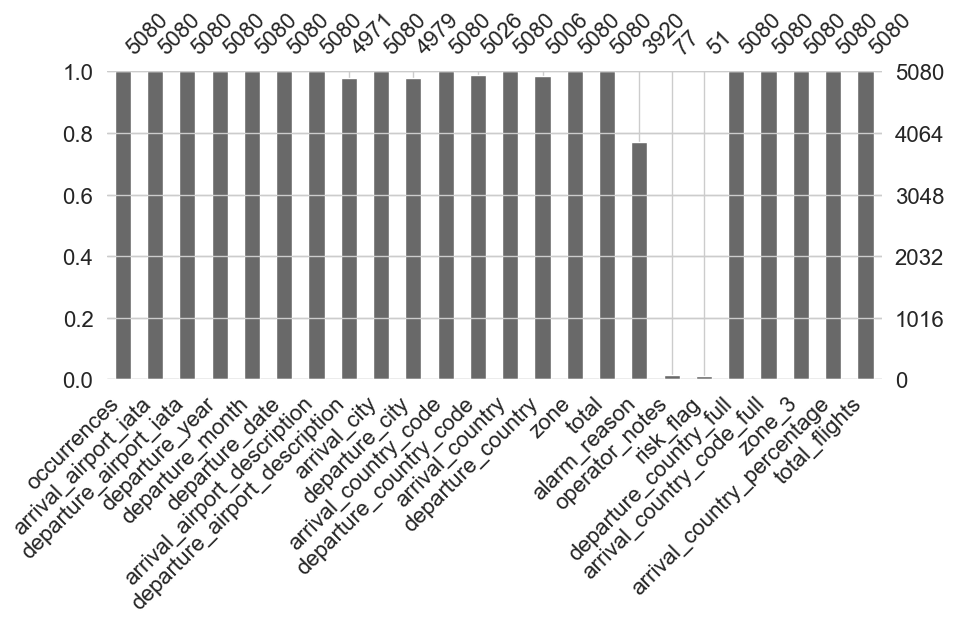

Missing Values - Travelers Dataset


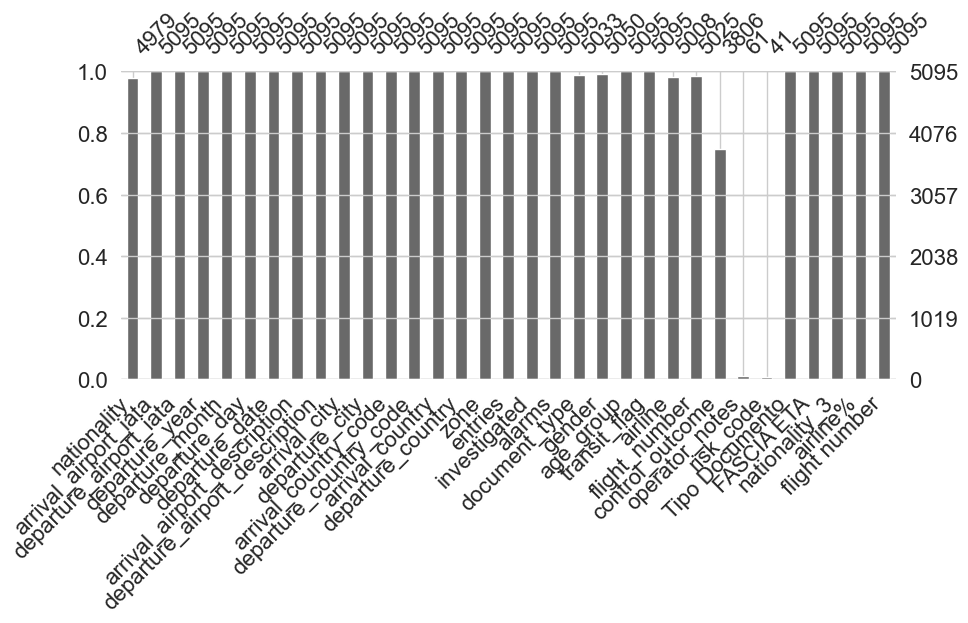

In [51]:
# Visualize missing values for the Alarms dataset
print("Missing Values - Alarms Dataset")
msno.bar(df_alarms, figsize=(10, 4))
plt.show()

# Visualize missing values for the Travelers dataset
print("Missing Values - Travelers Dataset")
msno.bar(df_travelers, figsize=(10, 4))
plt.show()

### Step 1.2: Categorical Features & Cardinality Inspection
Before cleaning the data (Step 2), we must inspect the categorical variables (text columns).   
We cap the visualization at 400 unique values to prevent Dates (e.g., `departure_date`) or dirty numerical columns (e.g., `TOT` loaded as strings) from skewing the chart.   

This step will:  
1. **Visualize the cardinality** of standard categorical features.  
2. **Highlight extremely high cardinality columns** (requiring Datetime conversion or numeric cleaning).  
3. **List the actual unique values** alphabetically to easily spot typos and standardization issues (e.g., "GB" vs "GDB").  


--- CATEGORICAL INSPECTION: ALARMS ---


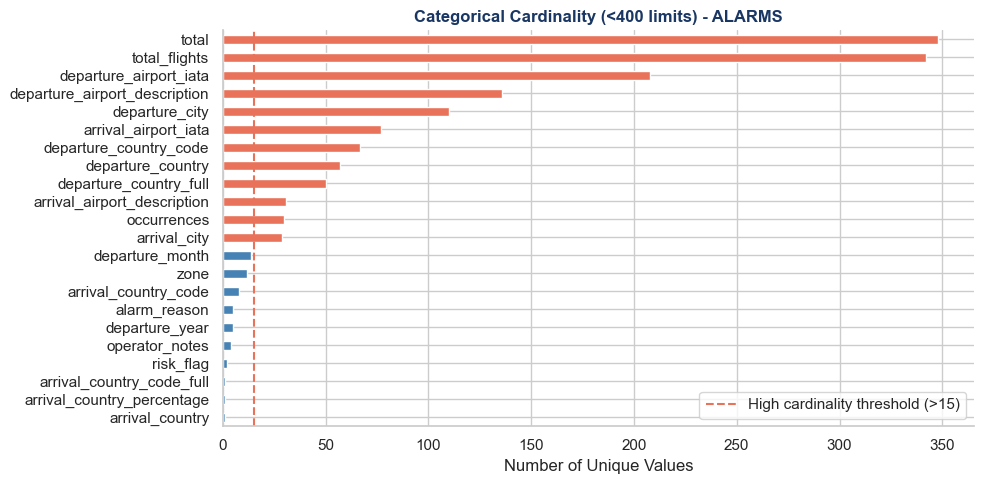


--- Unique Values Breakdown (ALARMS) ---
HIGH CARDINALITY FEATURES (Excluded from plot):
   ➤ 'departure_date': 3810 unique values (Action needed in Step 2: Deep analysis and cleaning)
--------------------------------------------------

 REVIEWING CATEGORIES (To spot typos/standardization issues):
➤ 'arrival_country' (1 values):
   ['Italia']

➤ 'arrival_country_percentage' (1 values):
   ['Italia']

➤ 'arrival_country_code_full' (1 values):
   ['ITA']

➤ 'risk_flag' (2 values):
   ['ALTO', 'MEDIO']

➤ 'operator_notes' (4 values):
   ['Alert manuale', 'Doppio controllo', 'Passeggero noto', 'Verifica richiesta']

➤ 'departure_year' (5 values):
   ['2023', '2024', '2024.', '24', 'anno 2024']

➤ 'alarm_reason' (5 values):
   ['INTERPOL', 'Manuale', 'NSIS', 'SDI', 'TSC']

➤ 'arrival_country_code' (8 values):
   ['DEU', 'ESP', 'FRA', 'GB', 'GBR', 'IT', 'ITA', 'TUR']

➤ 'zone' (12 values):
   ['-1', '1', '10', '2', '4', '5', '6', '7', '8', '9', '99', '??']

➤ 'departure_month' (14 values):


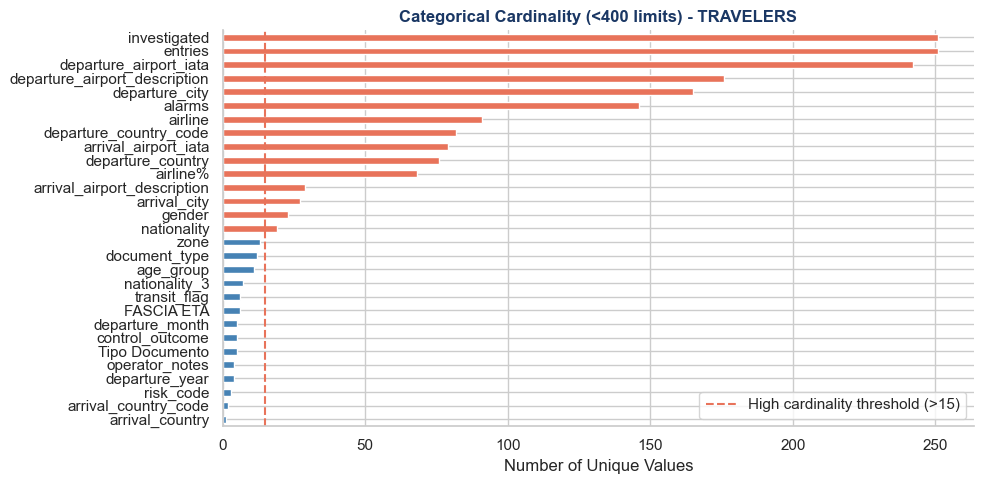


--- Unique Values Breakdown (TRAVELERS) ---
HIGH CARDINALITY FEATURES (Excluded from plot):
   ➤ 'flight_number': 701 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'flight number': 706 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'departure_date': 3977 unique values (Action needed in Step 2: Deep analysis and cleaning)
--------------------------------------------------

 REVIEWING CATEGORIES (To spot typos/standardization issues):
➤ 'arrival_country' (1 values):
   ['Italia']

➤ 'arrival_country_code' (2 values):
   ['IT', 'ITA']

➤ 'risk_code' (3 values):
   ['R1', 'R2', 'R3']

➤ 'departure_year' (4 values):
   ['2023', '2024', '24', 'anno 2024']

➤ 'operator_notes' (4 values):
   ['Alert manuale', 'Passeggero noto', 'Segnalazione esterna', 'Verifica richiesta']

➤ 'Tipo Documento' (5 values):
   ["Carta d'identità", 'N.D.', 'Passaporto', 'Permesso di soggiorno', 'Visto']

➤ 'control_outcome' (5 values):
   ['FERMATO', 'IN ATTESA

In [52]:
def inspect_categorical_clean(df, dataset_name):
    print(f"\n{'='*60}")
    print(f"--- CATEGORICAL INSPECTION: {dataset_name} ---")
    print(f"{'='*60}")
    
    # Select only categorical (text) columns
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) == 0:
        return
    
    # Calculate cardinality
    card = df[cat_cols].nunique().sort_values(ascending=True)
    
    # --- 1. FILTER FOR VISUALIZATION ---
    # Keep only columns with <= 400 unique values for the chart
    card_to_plot = card[card <= 400]
    high_card_cols = card[card > 400]
    
    if not card_to_plot.empty:
        plt.figure(figsize=(10, 5))
        colors = ['#E8735A' if v > 15 else '#4682B4' for v in card_to_plot]
        card_to_plot.plot(kind='barh', color=colors, edgecolor='white')
        plt.axvline(15, color='#E8735A', ls='--', lw=1.5, label='High cardinality threshold (>15)')
        plt.title(f'Categorical Cardinality (<400 limits) - {dataset_name}', fontweight='bold', color='#1A3764')
        plt.xlabel('Number of Unique Values')
        plt.legend()
        sns.despine()
        plt.tight_layout()
        plt.show()
    
    # --- 2. TEXT BREAKDOWN ---
    print(f"\n--- Unique Values Breakdown ({dataset_name}) ---")
    
    # Display the problematic columns we excluded from the chart
    if not high_card_cols.empty:
        print("HIGH CARDINALITY FEATURES (Excluded from plot):")
        for col, val in high_card_cols.items():
            print(f"   ➤ '{col}': {val} unique values (Action needed in Step 2: Deep analysis and cleaning)")
        print("-" * 50)
        
    print("\n REVIEWING CATEGORIES (To spot typos/standardization issues):")
    for col in card_to_plot.index:
        # Sort values alphabetically
        unique_vals = sorted(df[col].dropna().astype(str).unique())
        print(f"➤ '{col}' ({len(unique_vals)} values):")
        print(f"   {unique_vals}\n")

inspect_categorical_clean(df_alarms, "ALARMS")
inspect_categorical_clean(df_travelers, "TRAVELERS")

In [53]:
print(f"\n{'='*60}")
print("--- STEP 1: INSPECTING REDUNDANT COLUMNS (TRAVELERS) ---")
print(f"{'='*60}")

# Pairs of columns to check: (Main Column, Backup Column)
pairs_to_check = [
    ('document_type', 'Tipo Documento'),
    ('airline', 'airline%'),
    ('flight_number', 'flight number'),
    ('nationality', 'nationality_3'),
    ('age_group', 'FASCIA ETA')
]

for col1, col2 in pairs_to_check:
    # Verify both columns exist in the dataframe
    if col1 in df_travelers.columns and col2 in df_travelers.columns:
        
        # Find rows where BOTH columns have data, but the data is DIFFERENT
        # We use .astype(str).str.upper().str.strip() to ignore simple formatting differences
        mask_diff = df_travelers[col1].notna() & df_travelers[col2].notna() & \
                    (df_travelers[col1].astype(str).str.upper().str.strip() != 
                     df_travelers[col2].astype(str).str.upper().str.strip())
        
        conflicts = mask_diff.sum()
        
        print(f"➤ Comparing: '{col1}' vs '{col2}'")
        print(f"  - Conflicts found: {conflicts}")
        
        # Display examples if conflicts exist
        if conflicts > 0:
            print("  - Examples of conflicts:")
            display(df_travelers[mask_diff][[col1, col2]].head(3))
        print("-" * 50)


--- STEP 1: INSPECTING REDUNDANT COLUMNS (TRAVELERS) ---
➤ Comparing: 'document_type' vs 'Tipo Documento'
  - Conflicts found: 136
  - Examples of conflicts:


,document_type,Tipo Documento
18,?,Permesso di soggiorno
61,?,Permesso di soggiorno
155,?,N.D.


--------------------------------------------------
➤ Comparing: 'airline' vs 'airline%'
  - Conflicts found: 180
  - Examples of conflicts:


,airline,airline%
26,//,Turkish Airlines
28,?,Ryanair DAC
51,-,Easyjet


--------------------------------------------------
➤ Comparing: 'flight_number' vs 'flight number'
  - Conflicts found: 134
  - Examples of conflicts:


...

--------------------------------------------------
➤ Comparing: 'nationality' vs 'nationality_3'
  - Conflicts found: 205
  - Examples of conflicts:


,nationality,nationality_3
14,//,ALB
39,n.d.,ALB
61,,AFG


--------------------------------------------------
➤ Comparing: 'age_group' vs 'FASCIA ETA'
  - Conflicts found: 8
  - Examples of conflicts:


,age_group,FASCIA ETA
980,N/C,0-17
1573,minore,0-17
2701,-5,N.D.


--------------------------------------------------


In [55]:
# => Column that we keep : Typo documento (instead of document type); Fascia Eta (instead of age_group); nationality_3 (instead of nationality); flight number (instead of flight_number); airline% (instead of airline)
#TO BE VALIDATED BY GIULIO
#print(f"\n{'='*60}")
#print("--- STEP 2: APPLYING COLUMN CHOICES & STANDARDIZATION ---")
#print(f"{'='*60}")

# ---------------------------------------------------------
# ACTION 1: Drop rejected columns and rename the kept ones
# ---------------------------------------------------------

# Columns we decided to DROP
#cols_to_drop = ['document_type', 'age_group', 'nationality', 'flight_number', 'airline']
#df_travelers = df_travelers.drop(columns=cols_to_drop, errors='ignore')

# Rename the KEPT columns to clean English names
#rename_dict = {
   # 'Tipo Documento': 'document_type',
   # 'FASCIA ETA': 'age_group',
   # 'nationality_3': 'nationality',
   # 'flight number': 'flight_number',
   # 'airline%': 'airline'
}
#df_travelers = df_travelers.rename(columns=rename_dict)

#print("1. Redundant columns dropped and kept columns renamed successfully.")

In [56]:
# ---------------------------------------------------------
# ACTION 2: Text Standardization & Junk Values Removal
# ---------------------------------------------------------
import numpy as np

print(f"\n{'='*60}")
print("--- STEP 2: TEXT STANDARDIZATION & UNIFYING 'N.D.' ---")
print(f"{'='*60}")

# 1. Select all text (categorical) columns
text_cols = df_travelers.select_dtypes(include=['object']).columns

# 2. Global Standardization: Strip spaces and convert to UPPERCASE
# This automatically fixes issues like " nd ", "Unknown", or "N.D. "
for col in text_cols:
    df_travelers[col] = df_travelers[col].astype(str).str.strip().str.upper()

# 3. Standardize all "Unknown" variations into the official "N.D." format
# Since we already uppercased everything, we only need to look for uppercase variants
unknown_variants = ['ND', 'UNKNOWN', 'UNKN', 'N/A', 'N/C']
df_travelers[text_cols] = df_travelers[text_cols].replace(unknown_variants, 'N.D.')

# 4. Handle genuine junk values by converting them to actual pandas NaNs (Nulls)
# The string 'NAN' is generated when pandas converts an actual NaN to string in step 2
junk_values = ['-', '//', '?', '???', 'XX', 'ZZ', 'NAN', '']
df_travelers[text_cols] = df_travelers[text_cols].replace(junk_values, np.nan)

print("Standardization complete!")
print(" - Text converted to UPPERCASE and stripped of hidden spaces.")
print(" - All unknown variants (ND, UNKNOWN, N/C) unified to 'N.D.'.")
print(" - Junk symbols (-, ?, //) properly converted to NaN.")
print("-" * 60)

# Quick verification on a few key columns
cols_to_check = ['departure_airport_iata', 'arrival_airport_iata', 'gender']
for col in cols_to_check:
    if col in df_travelers.columns:
        print(f"Unique values in '{col}': {df_travelers[col].dropna().unique()}")


--- STEP 2: TEXT STANDARDIZATION & UNIFYING 'N.D.' ---
Standardization complete!
 - Text converted to UPPERCASE and stripped of hidden spaces.
 - All unknown variants (ND, UNKNOWN, N/C) unified to 'N.D.'.
 - Junk symbols (-, ?, //) properly converted to NaN.
------------------------------------------------------------
Unique values in 'departure_airport_iata': ['DUR' 'JFK' 'TIA' 'IST' 'MLE' 'LTN' 'SHJ' 'LHR' 'LGW' 'TUN' 'MIA' 'KBL'
 'IKA' 'SAW' 'EWR' 'BFS' 'MAN' 'IAD' 'ZNZ' 'STN' 'JED' 'PRN' 'ORD' 'SSH'
 'DXB' 'HAN' 'CLE' 'BHX' 'SKP' 'LAD' 'RUH' 'DFW' 'RAK' 'DOH' 'YYC' 'LCY'
 'TGD' 'GYD' 'EDI' 'MBA' 'TAS' 'KUT' 'BEG' 'GRU' 'AUH' 'ISB' 'SPX' 'MNL'
 'MRU' 'MEL' 'ADB' 'BKK' 'AMM' 'ICN' 'SOF' 'EVN' 'LRM' 'BRS' 'MEX' 'DPS'
 'YYZ' 'SIN' 'CVG' 'PEW' 'RMF' 'CAI' 'BUF' 'HRG' 'MCT' 'PEK' 'NCL' 'KUL'
 'MED' 'CMN' 'PVG' 'HKT' 'GZT' 'ELQ' 'CGK' 'MHD' 'LAX' 'DAR' 'NAV' 'SKG'
 'SDU' 'HND' 'YWG' 'TFU' 'POA' 'SGN' 'FLL' 'BNA' 'DWC' 'ABJ' 'GIG' 'BAH'
 'GLA' 'JAX' 'TLV' 'DEL' 'MJI' 'KIV' 'PER' 'TPA' 'NR

In [65]:
print(f"\n{'='*60}")
print("--- STEP 4: NUMERIC & SPECIFIC COLUMN STANDARDIZATION ---")
print(f"{'='*60}")

# ---------------------------------------------------------
# ACTION 1: Logical Mapping (Country, Year, Month)
# ---------------------------------------------------------

# 1. Arrival Country Code
if 'arrival_country_code' in df_travelers.columns:
    df_travelers['arrival_country_code'] = df_travelers['arrival_country_code'].replace({'IT': 'ITA'})

# 2. Departure Year (Catching both standard and uppercased formats)
if 'departure_year' in df_travelers.columns:
    year_map = {'24': '2024', 'ANNO 2024': '2024', 'anno 2024': '2024'}
    df_travelers['departure_year'] = df_travelers['departure_year'].replace(year_map)

# 3. Departure Month
if 'departure_month' in df_travelers.columns:
    month_map = {'GEN': '01', 'FEB': '02'}
    df_travelers['departure_month'] = df_travelers['departure_month'].replace(month_map)

print("1. Country, Year, and Month columns logically mapped.")

# ---------------------------------------------------------
# ACTION 2: Numeric Standardization (entries, investigated, alarms)
# ---------------------------------------------------------

quant_cols = ['entries', 'investigated', 'alarms']

for col in quant_cols:
    if col in df_travelers.columns:
        # Step A: Replace Italian comma with decimal dot (e.g., '1,0' -> '1.0')
        df_travelers[col] = df_travelers[col].astype(str).str.replace(',', '.')
        
        # Step B: Regex to remove all characters except digits, minus sign, and decimal dot
        # This automatically destroys ' PAX', '~', and 'N.D.' turning them into clean numbers or empty strings
        df_travelers[col] = df_travelers[col].str.replace(r'[^\d\.\-]', '', regex=True)
        
        # Step C: Convert to float (errors='coerce' turns empty strings into NaN)
        df_travelers[col] = pd.to_numeric(df_travelers[col], errors='coerce')
        
        # Step D: Business Logic Filter
        # Passengers cannot be negative. Also, a single cohort > 1000 on a flight is likely a typo (like 9999).
        # We replace these unrealistic values with NaN so they don't break the ML model.
        df_travelers.loc[(df_travelers[col] < 0) | (df_travelers[col] > 1000), col] = np.nan
        
        # Step E: Convert to Nullable Integer type ('Int64') since we can't have 1.5 people
        df_travelers[col] = df_travelers[col].astype('Int64')

print("2. 'entries', 'investigated' and 'alarms' cleaned and converted to nullable integers (Int64).")

# ---------------------------------------------------------
# ACTION 3: Cleaning the 'zone' column
# ---------------------------------------------------------

if 'zone' in df_travelers.columns:
    # Remove junk like '??'
    df_travelers['zone'] = df_travelers['zone'].astype(str).str.strip()
    df_travelers['zone'] = df_travelers['zone'].replace(['??', '?', '-'], np.nan)
    
    # Convert to numeric
    df_travelers['zone'] = pd.to_numeric(df_travelers['zone'], errors='coerce')
    
    # Business Logic Filter: Zones should be between 0 and 10.
    # We replace error codes like '-1' or '99' with NaN
    df_travelers.loc[(df_travelers['zone'] < 0) | (df_travelers['zone'] > 10), 'zone'] = np.nan
    
    # Convert to Nullable Integer ('Int64')
    df_travelers['zone'] = df_travelers['zone'].astype('Int64')

print("3. 'zone' successfully cleaned (values restricted to 0-10).")
print("-" * 60)

# ---------------------------------------------------------
# ACTION 4: Gender Standardization
# ---------------------------------------------------------
if 'gender' in df_travelers.columns:
    gender_map = {
        '1': 'M', 'MALE': 'M', 'MASCHIO': 'M', 'M': 'M',
        '2': 'F', 'FEMALE': 'F', 'FEMMINA': 'F', 'F': 'F',
        'N/B': 'X', 'X': 'X'  # 'X' is the international passport standard for Unspecified/Non-Binary
        # 'N.D.' will remain untouched as intended
    }
    df_travelers['gender'] = df_travelers['gender'].replace(gender_map)
    
    print("➤ Gender column standardized.")
    print(f"  Unique valid values now: {sorted(df_travelers['gender'].dropna().unique())}")
    print("-" * 60)

# ---------------------------------------------------------
# VERIFICATION
# ---------------------------------------------------------
print("➤ Quick Verification:")
if 'arrival_country_code' in df_travelers.columns:
    print(f"  - arrival_country_code: {df_travelers['arrival_country_code'].dropna().unique()}")
if 'departure_year' in df_travelers.columns:
    print(f"  - departure_year: {df_travelers['departure_year'].dropna().unique()}")
if 'departure_month' in df_travelers.columns:
    print(f"  - departure_month: {df_travelers['departure_month'].dropna().unique()}")
if 'entries' in df_travelers.columns:
    print(f"  - entries type: {df_travelers['entries'].dtype}")
    print(f"  - entries min/max: {df_travelers['entries'].min()} to {df_travelers['entries'].max()}")
if 'zone' in df_travelers.columns:
    print(f"  - zone type: {df_travelers['zone'].dtype}")
    print(f"  - zone unique valid values: {sorted(df_travelers['zone'].dropna().unique())}")


--- STEP 4: NUMERIC & SPECIFIC COLUMN STANDARDIZATION ---
1. Country, Year, and Month columns logically mapped.
2. 'entries', 'investigated' and 'alarms' cleaned and converted to nullable integers (Int64).
3. 'zone' successfully cleaned (values restricted to 0-10).
------------------------------------------------------------
➤ Gender column standardized.
  Unique valid values now: ['F', 'M', 'N.D.', 'X']
------------------------------------------------------------
➤ Quick Verification:
  - arrival_country_code: ['ITA']
  - departure_year: ['2024' '2023']
  - departure_month: ['02' '01' '12']
  - entries type: Int64
  - entries min/max: 0 to 186
  - zone type: Int64
  - zone unique valid values: [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [66]:
# ---------------------------------------------------------
# ACTION 2: The "Moment of Truth" - Missing Values Report
# ---------------------------------------------------------
print("➤ MISSING VALUES SUMMARY (True NaNs):")

# Count missing values per column
missing_counts = df_travelers.isna().sum()

# Filter only columns that actually have missing values and sort them descending
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

if missing_counts.empty:
    print("  Wow! 0 missing values in the entire dataset!")
else:
    # Calculate the percentage for business context
    missing_percent = (missing_counts / len(df_travelers)) * 100
    
    # Create a nice DataFrame to display the results cleanly
    missing_report = pd.DataFrame({
        'Missing Values': missing_counts, 
        'Percentage (%)': missing_percent.round(2)
    })
    display(missing_report)

print("-" * 60)

➤ MISSING VALUES SUMMARY (True NaNs):


,Missing Values,Percentage (%)
risk_code,5054,99.20
operator_notes,5034,98.80
control_outcome,1289,25.30
nationality,232,4.55
airline,192,3.77
flight_number,141,2.77
document_type,140,2.75
gender,110,2.16
entries,91,1.79
investigated,91,1.79


------------------------------------------------------------


In [67]:
# IT is ok globally! 
#For risk and operator_notes code we'll do the same as in alarms dataset
#For control outcome, we should do as suggered by Anna, an imputation methods
#for nationality, airline, flight_number, document_type => AS they are redundant, we don't care
# for gender, entries, investigated, alarms, zone, we should use either mean, mode because only few percents

In [68]:
import re

def extract_pattern(val):
    s = str(val)
    s = re.sub(r'\d', 'N', s)
    s = re.sub(r'[a-zA-Z]', 'A', s)  
    return s

pattern_counts = (
    df_travelers['departure_date']
    .dropna()
    .map(extract_pattern)
    .value_counts()
)

print(pattern_counts)

departure_date
AAAA-AA-AA AA:AA:AA    4689
AAA AA AAAA              81
AA-AA-AA                 70
AAAA-AA-AAAAA:AA:AA      68
AAAA/AA/AA               66
AA/AA/AAAA AA:AA:AA      66
AA.AA.AAAA               55
Name: count, dtype: int64


In [46]:
import re

def estrai_pattern(val):
    s = str(val)
    s = re.sub(r'\d', 'N', s)
    s = re.sub(r'[a-zA-Z]', 'A', s)  
    return s

pattern_counts = (
    df_alarms['departure_date']
    .dropna()
    .map(estrai_pattern)
    .value_counts()
)

print(pattern_counts)
# mode for hour 

departure_date
AAAA-AA-AA AA:AA:AA    4675
AA-AA-AA                 76
AAAA/AA/AA               76
AAA AA AAAA              68
AA.AA.AAAA               62
AAAA-AA-AAAAA:AA:AA      62
AA/AA/AAAA AA:AA:AA      61
Name: count, dtype: int64


In [1536]:
# fix AA/AA/AAAA AA:AA:AA
df_alarms['departure_date'] = df_alarms['departure_date'].astype(str).str.replace(r'(\d{2})/(\d{2})/(\d{4}) (\d{2}):(\d{2}):(\d{2})', r'\3-\2-\1 \4:\5:\6', regex=True)
# from AAAA-AA-AAAAA:AA:AA to AAAA-AA-AA AA:AA:AA
df_alarms['departure_date'] = df_alarms['departure_date'].astype(str).str.replace(r'(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})', r'\1 \2', regex=True)
# from AAAA/AA/AA to AAAA-AA-AA AA:AA:AA where time will be missing
df_alarms['departure_date'] = df_alarms['departure_date'].astype(str).str.replace(r'(\d{4})/(\d{2})/(\d{2})', r'\1-\2-\3 00:00:00', regex=True)
# from AA.AA.AAAA to AAAA-AA-AA AA:AA:AA where time will be missing
df_alarms['departure_date'] = df_alarms['departure_date'].astype(str).str.replace(r'(\d{2})\.(\d{2})\.(\d{4})', r'\3-\2-\1 00:00:00', regex=True)
# from AAA AA AAAA to AAAA-AA-AA AA:AA:AA where time will be missing
df_alarms['departure_date'] = pd.to_datetime(
    df_alarms['departure_date'].astype(str).str.extract(r'([A-Za-z]{3} \d{2} \d{4})')[0],
    format='%b %d %Y',
    errors='coerce'
).dt.strftime('%Y-%m-%d 00:00:00').fillna(df_alarms['departure_date'])
# from AA-AA-AA to AAAA-AA-AA AA:AA:AA where time will be missing
df_alarms['departure_date'] = df_alarms['departure_date'].astype(str).str.replace(
    r'^(\d{2})-(\d{2})-(\d{2})$', 
    lambda m: f'20{m.group(3)}-{m.group(2)}-{m.group(1)} 00:00:00', 
    regex=True
)

In [1537]:
import re

def estrai_pattern(val):
    s = str(val)
    s = re.sub(r'\d', 'N', s)
    s = re.sub(r'[a-zA-Z]', 'A', s)  
    return s

pattern_counts = (
    df_alarms['departure_date']
    .dropna()
    .map(estrai_pattern)
    .value_counts()
)

print(pattern_counts)
# TODO I'LL FINISH LATER

departure_date
AAAA-AA-AA AA:AA:AA    4986
AAAA-AA-AAAAA:AA:AA      62
AAA AA AAAA              32
Name: count, dtype: int64


### Step 2: Data Cleaning & Preprocessing
Initial inspection revealed that pandas loaded almost all columns as strings (`object`).   
To perform summary statistics pragmatically, we cast temporal features to `datetime` and quantitative features to `numeric`.  
Bad data (e.g., text in a number column) is coerced to NaN.  

In [1538]:
# --- 1. Dates and Temporal Categories ---
# We convert the full date to datetime, but leave ANNO (Year) and MESE (Month) as objects (categorical)
df_alarms['departure_date'] = pd.to_datetime(df_alarms['departure_date'], errors='coerce')
df_travelers['departure_date'] = pd.to_datetime(df_travelers['departure_date'], errors='coerce')

# --- 2. Forcing Quantitative Variables to Numeric ---
# 'coerce' will turn any hidden text (like "N/A" or " ") into a clean NaN (Missing Value)
quant_alarms = ['total', 'zone_3', 'total_flights', 'zone']
df_alarms[quant_alarms] = df_alarms[quant_alarms].apply(pd.to_numeric, errors='coerce')

quant_travelers = ['entries', 'investigated', 'alarms']
df_travelers[quant_travelers] = df_travelers[quant_travelers].apply(pd.to_numeric, errors='coerce')

# --- 3. Verification ---
print("Conversion Complete.")
print(f"Alarms dataset now has {len(df_alarms.select_dtypes(include=['float64', 'int64']).columns)} numerical columns.")
print(f"Travelers dataset now has {len(df_travelers.select_dtypes(include=['float64', 'int64']).columns)} numerical columns.")

Conversion Complete.
Alarms dataset now has 4 numerical columns.
Travelers dataset now has 4 numerical columns.


In [1539]:
# Data cleaning on ALARMS dataset
df_alarms.columns = df_alarms.columns.str.upper()
missing_tokens = ['', '-', '//', '?', 'n.d.', 'nd', 'n/a', 'null', 'unknown', 'N.D.', 'ND', 'UNKNOWN', 'XX', 'ZZ', '00']

df_alarms[['ARRIVAL_AIRPORT_IATA', 'DEPARTURE_COUNTRY_CODE', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ARRIVAL_COUNTRY_CODE_FULL']] = df_alarms[[
    'ARRIVAL_AIRPORT_IATA', 'DEPARTURE_COUNTRY_CODE', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ARRIVAL_COUNTRY_CODE_FULL']].apply(lambda x: x.str.strip().str.upper())

df_alarms[['ARRIVAL_AIRPORT_DESCRIPTION', 'DEPARTURE_AIRPORT_DESCRIPTION', 'ARRIVAL_CITY', 'DEPARTURE_CITY', 'DEPARTURE_COUNTRY', 'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_PERCENTAGE', 'DEPARTURE_COUNTRY_FULL']] = df_alarms[[
    'ARRIVAL_AIRPORT_DESCRIPTION', 'DEPARTURE_AIRPORT_DESCRIPTION', 'ARRIVAL_CITY', 'DEPARTURE_CITY', 'DEPARTURE_COUNTRY', 'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_PERCENTAGE', 'DEPARTURE_COUNTRY_FULL']].apply(lambda x: x.str.strip().str.capitalize())

# We clean the month and year columns to analyse it
df_alarms['DEPARTURE_MONTH'] = df_alarms['DEPARTURE_MONTH'].replace({
    'GEN': '01', 'FEB': '02', 'MAR': '03', 'APR': '04', 'MAG': '05', 'GIU': '06',
    'LUG': '07', 'AGO': '08', 'SET': '09', 'OTT': '10', 'NOV': '11', 'DIC': '12'})
df_alarms['DEPARTURE_YEAR'] = df_alarms['DEPARTURE_YEAR'].replace({
    '2024.': '2024', '24': '2024', 'anno 2024': '2024'})

# After distribution analysis of departure date, we decide to drop departure_year and departure_month as they are uncorrect.
df_alarms.drop(columns=['DEPARTURE_YEAR', 'DEPARTURE_MONTH'], inplace=True)

# TODO add comment
df_alarms.loc[df_alarms['ARRIVAL_COUNTRY'] == 'Italia', 'ARRIVAL_COUNTRY_CODE'] = 'ITA'

# TODO add comment
df_alarms['DEPARTURE_COUNTRY'] = df_alarms['DEPARTURE_COUNTRY_FULL'].combine_first(df_alarms['DEPARTURE_COUNTRY'])

# We standardize the RISK_FLAG values to be consistent and fill missing with 'LOW'
df_alarms['RISK_FLAG'] = df_alarms['RISK_FLAG'].fillna('LOW')
df_alarms['RISK_FLAG'] = df_alarms['RISK_FLAG'].str.upper().replace({'ALTO': 'HIGH', 'MEDIO': 'MEDIUM'})

# We fill missing values in OPERATOR_NOTES and ALARM_REASON with a placeholder text to avoid issues in analysis and to acknowledge that the information is missing.
df_alarms['OPERATOR_NOTES'] = df_alarms['OPERATOR_NOTES'].fillna('No notes provided')
df_alarms['ALARM_REASON'] = df_alarms['ALARM_REASON'].fillna('No reason provided')


In [1540]:
#Cleaning Departure Country and Country Code
def get_alpha3_from_italian_country(country_it):
    if pd.isna(country_it):
        return np.nan
    
    country_it = str(country_it).strip()
    country_en = it_to_en.get(country_it)
    
    if not country_en:
        return np.nan
    
    # Kosovo special case
    if country_it == 'Cossovo':
        return 'RKS'
    
    try:
        return pycountry.countries.lookup(country_en).alpha_3
    except LookupError:
        return np.nan

df_alarms['DEPARTURE_COUNTRY_CODE'] = df_alarms['DEPARTURE_COUNTRY'].apply(get_alpha3_from_italian_country)


In [1541]:
# cleaning departure city
df_alarms['DEPARTURE_CITY'] = df_alarms['DEPARTURE_CITY'].replace(city_mapping)
for col in ['DEPARTURE_CITY', 'DEPARTURE_AIRPORT_DESCRIPTION']:
    df_alarms[col] = df_alarms[col].replace(missing_tokens, np.nan)

def clean_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = ' '.join(x.split())
    return x.title()

df_alarms['DEPARTURE_CITY'] = df_alarms['DEPARTURE_CITY'].apply(clean_text)
df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'] = df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].apply(clean_text)

In [1542]:
def fill_city_from_iata(iata):
    if pd.isna(iata):
        return np.nan
    return iata_mapping.get(iata, {}).get('city', np.nan)

def fill_airport_from_iata(iata):
    if pd.isna(iata):
        return np.nan
    return iata_mapping.get(iata, {}).get('airport', np.nan)

mapped_city = df_alarms['DEPARTURE_AIRPORT_IATA'].map(fill_city_from_iata)
mapped_airport = df_alarms['DEPARTURE_AIRPORT_IATA'].map(fill_airport_from_iata)

df_alarms['DEPARTURE_CITY'] = df_alarms['DEPARTURE_CITY'].fillna(mapped_city)
df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'] = df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].fillna(mapped_airport)

In [1543]:
# TODO move this cell after all the cleaning steps and edit the column choosen for the final dataset
# Subset of cleaned columns 
df_alarms_clean = df_alarms[[
    'DEPARTURE_DATE', 
    'OCCURRENCES', 'RISK_FLAG', 'ALARM_REASON', 'OPERATOR_NOTES',
    'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ARRIVAL_CITY', 'ARRIVAL_AIRPORT_DESCRIPTION', 'ARRIVAL_AIRPORT_IATA', 
    'DEPARTURE_COUNTRY', 'DEPARTURE_COUNTRY_CODE', 'DEPARTURE_CITY', 'DEPARTURE_AIRPORT_DESCRIPTION', 'DEPARTURE_AIRPORT_IATA',
    'ZONE', 'ZONE_3', 'TOTAL_FLIGHTS', 'TOTAL'
]]


--- CATEGORICAL INSPECTION: ALARMS ---


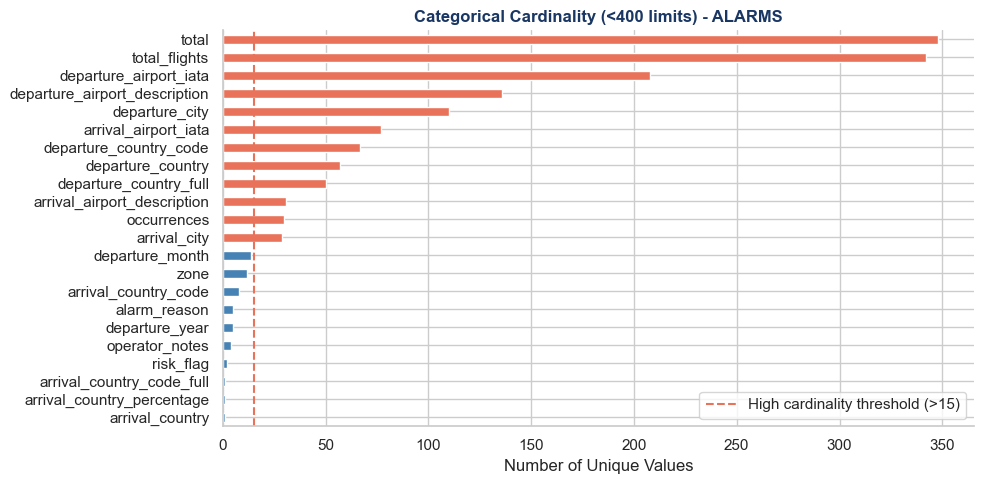


--- Unique Values Breakdown (ALARMS) ---
HIGH CARDINALITY FEATURES (Excluded from plot):
   ➤ 'departure_date': 3810 unique values (Action needed in Step 2: Deep analysis and cleaning)
--------------------------------------------------

 REVIEWING CATEGORIES (To spot typos/standardization issues):
➤ 'arrival_country' (1 values):
   ['Italia']

➤ 'arrival_country_percentage' (1 values):
   ['Italia']

➤ 'arrival_country_code_full' (1 values):
   ['ITA']

➤ 'risk_flag' (2 values):
   ['ALTO', 'MEDIO']

➤ 'operator_notes' (4 values):
   ['Alert manuale', 'Doppio controllo', 'Passeggero noto', 'Verifica richiesta']

➤ 'departure_year' (5 values):
   ['2023', '2024', '2024.', '24', 'anno 2024']

➤ 'alarm_reason' (5 values):
   ['INTERPOL', 'Manuale', 'NSIS', 'SDI', 'TSC']

➤ 'arrival_country_code' (8 values):
   ['DEU', 'ESP', 'FRA', 'GB', 'GBR', 'IT', 'ITA', 'TUR']

➤ 'zone' (12 values):
   ['-1', '1', '10', '2', '4', '5', '6', '7', '8', '9', '99', '??']

➤ 'departure_month' (14 values):


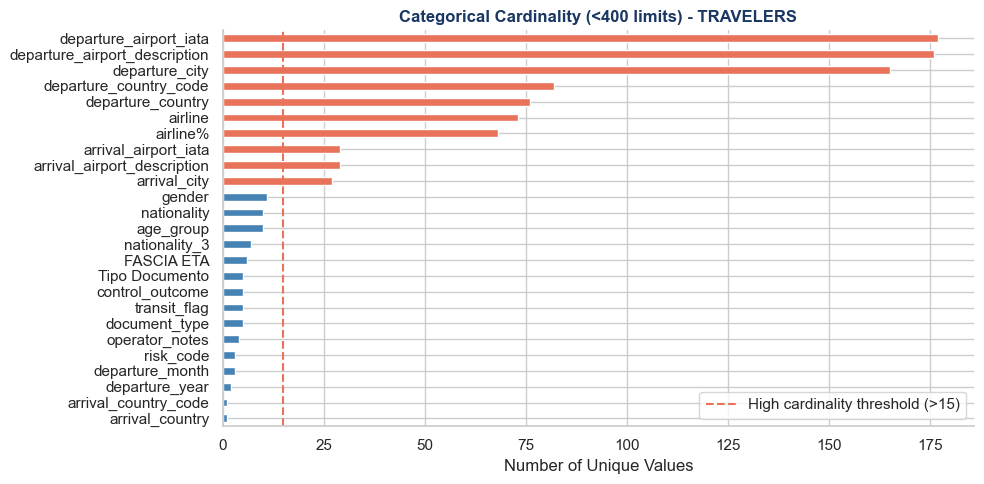


--- Unique Values Breakdown (TRAVELERS) ---
HIGH CARDINALITY FEATURES (Excluded from plot):
   ➤ 'flight_number': 593 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'flight number': 601 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'departure_date': 3977 unique values (Action needed in Step 2: Deep analysis and cleaning)
--------------------------------------------------

 REVIEWING CATEGORIES (To spot typos/standardization issues):
➤ 'arrival_country' (1 values):
   ['ITALIA']

➤ 'arrival_country_code' (1 values):
   ['ITA']

➤ 'departure_year' (2 values):
   ['2023', '2024']

➤ 'departure_month' (3 values):
   ['01', '02', '12']

➤ 'risk_code' (3 values):
   ['R1', 'R2', 'R3']

➤ 'operator_notes' (4 values):
   ['ALERT MANUALE', 'PASSEGGERO NOTO', 'SEGNALAZIONE ESTERNA', 'VERIFICA RICHIESTA']

➤ 'document_type' (5 values):
   ["CARTA D'IDENTITÀ", 'N.D.', 'PASSAPORTO', 'PERMESSO DI SOGGIORNO', 'VISTO']

➤ 'transit_flag' (5 values):

In [64]:
def inspect_categorical_clean(df, dataset_name):
    print(f"\n{'='*60}")
    print(f"--- CATEGORICAL INSPECTION: {dataset_name} ---")
    print(f"{'='*60}")
    
    # Select only categorical (text) columns
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) == 0:
        return
    
    # Calculate cardinality
    card = df[cat_cols].nunique().sort_values(ascending=True)
    
    # --- 1. FILTER FOR VISUALIZATION ---
    # Keep only columns with <= 400 unique values for the chart
    card_to_plot = card[card <= 400]
    high_card_cols = card[card > 400]
    
    if not card_to_plot.empty:
        plt.figure(figsize=(10, 5))
        colors = ['#E8735A' if v > 15 else '#4682B4' for v in card_to_plot]
        card_to_plot.plot(kind='barh', color=colors, edgecolor='white')
        plt.axvline(15, color='#E8735A', ls='--', lw=1.5, label='High cardinality threshold (>15)')
        plt.title(f'Categorical Cardinality (<400 limits) - {dataset_name}', fontweight='bold', color='#1A3764')
        plt.xlabel('Number of Unique Values')
        plt.legend()
        sns.despine()
        plt.tight_layout()
        plt.show()
    
    # --- 2. TEXT BREAKDOWN ---
    print(f"\n--- Unique Values Breakdown ({dataset_name}) ---")
    
    # Display the problematic columns we excluded from the chart
    if not high_card_cols.empty:
        print("HIGH CARDINALITY FEATURES (Excluded from plot):")
        for col, val in high_card_cols.items():
            print(f"   ➤ '{col}': {val} unique values (Action needed in Step 2: Deep analysis and cleaning)")
        print("-" * 50)
        
    print("\n REVIEWING CATEGORIES (To spot typos/standardization issues):")
    for col in card_to_plot.index:
        # Sort values alphabetically
        unique_vals = sorted(df[col].dropna().astype(str).unique())
        print(f"➤ '{col}' ({len(unique_vals)} values):")
        print(f"   {unique_vals}\n")

inspect_categorical_clean(df_alarms, "ALARMS")
inspect_categorical_clean(df_travelers, "TRAVELERS")

In [1545]:
# TODO remove after inspection
# Count na for each column in df_alarms
na_counts = df_alarms.isna().sum()
na_percentages = (na_counts / len(df_alarms) * 100).round(2)
na_summary = pd.DataFrame({
    'Missing Values': na_counts,
    'Missing Percentage': na_percentages
}).sort_values(by='Missing Values', ascending=False)
print("\nMissing Values Summary for ALARMS Dataset:")
display(na_summary)


Missing Values Summary for ALARMS Dataset:


,Missing Values,Missing Percentage
DEPARTURE_COUNTRY_CODE,443,8.72
TOTAL_FLIGHTS,156,3.07
TOTAL,156,3.07
DEPARTURE_DATE,94,1.85
DEPARTURE_AIRPORT_DESCRIPTION,5,0.10
ZONE,5,0.10
DEPARTURE_CITY,3,0.06
ALARM_REASON,0,0.00
ARRIVAL_COUNTRY_PERCENTAGE,0,0.00
ZONE_3,0,0.00


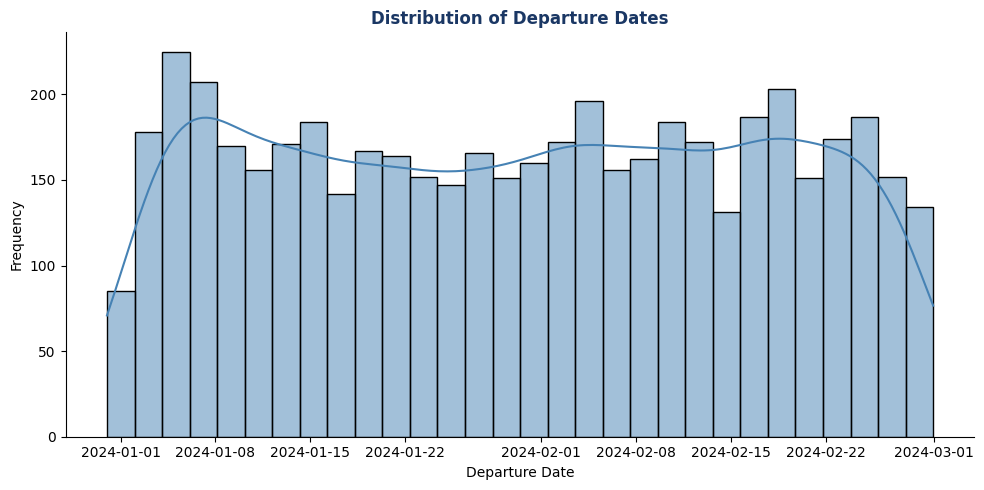

In [1546]:
# TODO remove after inspection
# distribution of dates 
plt.figure(figsize=(10, 5))
sns.histplot(df_alarms['DEPARTURE_DATE'], bins=30, kde=True, color='#4682B4')
plt.title('Distribution of Departure Dates', fontweight='bold', color='#1A3764')
plt.xlabel('Departure Date')
plt.ylabel('Frequency')
sns.despine()
plt.tight_layout()
plt.show()

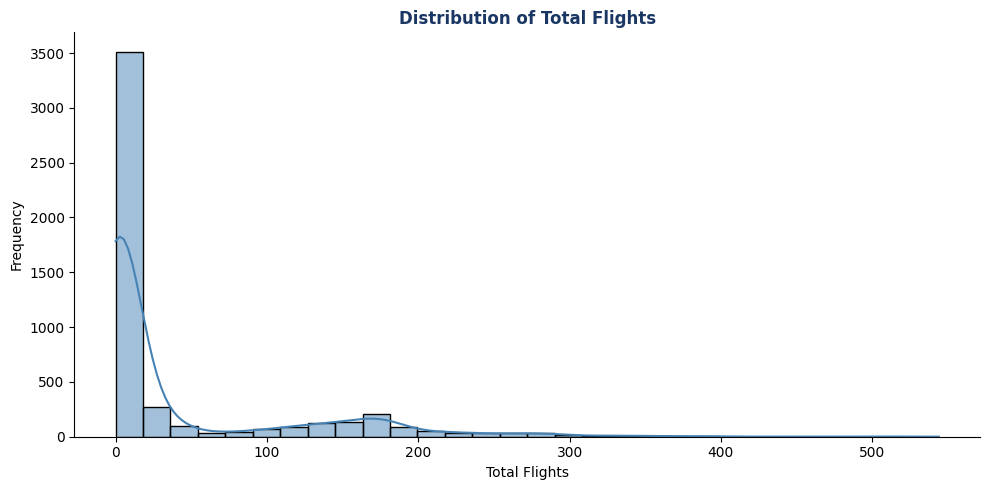

In [1547]:
# TODO remove after inspection
# GRAPHIC DISTRIBUTION OF TOTAL FLIGHT 
plt.figure(figsize=(10, 5))
sns.histplot(df_alarms['TOTAL_FLIGHTS'], bins=30, kde=True, color='#4682B4')
plt.title('Distribution of Total Flights', fontweight='bold', color='#1A3764')
plt.xlabel('Total Flights')
plt.ylabel('Frequency')
sns.despine()
plt.tight_layout()
plt.show()


In [1548]:
# TODO remove after inspection
# SEE IF TOTAL FLIGHTS HAS THESAME VALUE OF TOTAL
df_alarms['TOTAL_FLIGHTS'].equals(df_alarms['TOTAL'])
#SEE WHERE THEY DIFFER
df_alarms[df_alarms['TOTAL_FLIGHTS'] != df_alarms['TOTAL']][['TOTAL_FLIGHTS', 'TOTAL']]
# see all the different values
df_alarms[df_alarms['TOTAL_FLIGHTS'] != df_alarms['TOTAL']][['TOTAL_FLIGHTS', 'TOTAL']].drop_duplicates()
# For the moment (30/03) we replace missing_values in total_flights with mode and we drop total column

,TOTAL_FLIGHTS,TOTAL
22,1.0,2.0
23,1.0,-500.0
36,NaN,NaN
317,8.0,7.0
342,1.0,-1.0
1038,72.0,99999.0
1095,11.0,10.0
1381,6.0,7.0
1487,1.0,0.0
2119,184.0,0.0


In [1549]:
# TODO remove after inspection
# Zone is equal to zone_3?'
df_alarms['ZONE'].equals(df_alarms['ZONE_3'])
#SEE WHERE THEY DIFFER
df_alarms[df_alarms['ZONE'] != df_alarms['ZONE_3']][['ZONE', 'ZONE_3']]
# If the ZOne and ZOne3 columns represent the same information, we can drop one of them. We will keep ZONE_3 as it is more complete.

,ZONE,ZONE_3
652,-1.0,2
793,NaN,2
856,NaN,6
1855,NaN,2
2218,99.0,4
2224,10.0,8
2674,NaN,4
3389,NaN,5
3627,-1.0,4
4235,-1.0,5


### Step 3: Summary Statistics (Center, Spread, Shape) & First Insights & Trends
With proper data types established, we compute the summary statistics for our quantitative features. This analysis focuses on the three pillars:
1. **Center**: Mean and Median (50th percentile).
2. **Spread**: Standard Deviation (std) and Min/Max ranges to detect impossible values.
3. **Shape**: Skewness to identify highly asymmetrical distributions (where Skewness > 1 indicates a strong right tail, typical in anomaly/fraud detection).
# NEED to be finish and make it clearer

In [1550]:
# --- Step 3: Summary Statistics ---

# Define the true quantitative variables based on our dictionary
quant_travelers = ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']
quant_alarms = ['TOT', 'tot voli']

print("="*50)
print("--- 3A. SUMMARY STATISTICS: TRAVELERS ---")
print("="*50)
# Display Center and Spread (describe calculates count, mean, std, min, quartiles, max)
display(df_travelers[quant_travelers].describe().T.round(2))

print("\n--- SHAPE (SKEWNESS): TRAVELERS ---")
# Calculate Skewness and flag highly skewed features
skew_trav = df_travelers[quant_travelers].skew().round(2)
skew_df_trav = pd.DataFrame({'Skewness': skew_trav})
skew_df_trav['High_Skew_Flag'] = skew_df_trav['Skewness'].abs() > 1
display(skew_df_trav)

print("\n" + "="*50)
print("--- 3B. SUMMARY STATISTICS: ALARMS ---")
print("="*50)
display(df_alarms[quant_alarms].describe().T.round(2))

print("\n--- SHAPE (SKEWNESS): ALARMS ---")
skew_al = df_alarms[quant_alarms].skew().round(2)
skew_df_al = pd.DataFrame({'Skewness': skew_al})
skew_df_al['High_Skew_Flag'] = skew_df_al['Skewness'].abs() > 1
display(skew_df_al)

--- 3A. SUMMARY STATISTICS: TRAVELERS ---


KeyError: "None of [Index(['ENTRATI', 'INVESTIGATI', 'ALLARMATI'], dtype='object')] are in the [columns]"